# Imports

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils as nn_utils
from torch.nn.utils import spectral_norm

import os
import random

import torch.optim as optim
from sklearn.model_selection import train_test_split 
import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import plotly.graph_objects as go

import datetime 

import statistics
from tqdm import tqdm

import cv2

import lpips
from scipy.stats import wilcoxon
from skimage.metrics import structural_similarity as ssim

from torchvision.utils import save_image
from torch_fidelity import calculate_metrics


# Constants

In [22]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE  = "cpu"
print(DEVICE)


cpu


# Helper functions

In [23]:
def plot_class_distribution(class_percentage):
    """
    Plot the class distribution as a bar chart.
    
    Parameters:
    - class_percentage: dictionary with class IDs as keys and their respective percentage of pixels.
    """
    classes = list(class_percentage.keys())
    percentages = list(class_percentage.values())
    
    plt.bar(classes, percentages, color='b', alpha=0.7)
    plt.xlabel('Class ID')
    plt.ylabel('Percentage of Pixels (%)')
    plt.title('Class Distribution Across Dataset')
    plt.xticks(classes)  # Ensure all class IDs are labeled on the x-axis
    plt.show()
    
def calculate_overall_class_distribution(labels_dataset, include_no_data=True, show_plot=True):
    """
    Calculate the overall class distribution across all patches in the dataset.
    
    Parameters:
    - labels_dataset: numpy array of shape (num_patches, 64, 64) representing the patches.
    
    Returns:
    - overall_class_percentage: dictionary with the class ID as key and percentage of pixels across all patches.
    """
    if include_no_data:
        overall_class_counts = {i: 0 for i in (set(range(0, 10)))} # Assuming 10 classes
    else:
        overall_class_counts = {i: 0 for i in range(1, 10)}
    total_pixels = 0

    # Loop through all patches in the dataset
    for labels_patch in labels_dataset:
        flattened_patch = labels_patch.flatten()
        total_pixels += flattened_patch.size
        
        # Count class pixels in the current patch
        class_counts = {i: np.sum(flattened_patch == i) for i in overall_class_counts.keys()}

        for cls, count in class_counts.items():
            overall_class_counts[cls] += count

    # Calculate the percentage for each class across all patches
    overall_class_percentage = {cls: (count / total_pixels) * 100 for cls, count in overall_class_counts.items()}   

    if show_plot:
        plot_class_distribution(overall_class_percentage)
    
    return overall_class_percentage


# Load Data

In [24]:
data = np.load('../Dataset/s2-utm-33N-18E-242N-2018/DS3/11_final_gan_data_without_mixed_patches_64X64_majority50.npy')
labels = np.load('../Dataset/s2-utm-33N-18E-242N-2018/DS3/12_final_gan_labels_without_mixed_patches_64X64_majority50.npy')


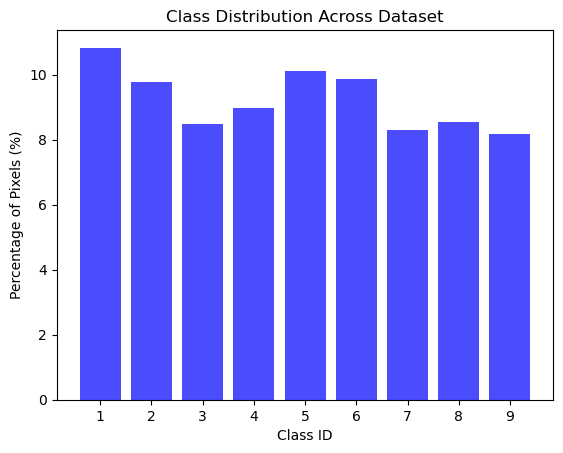

{1: 10.827362247686237,
 2: 9.781666308837725,
 3: 8.48157173553543,
 4: 8.963282314615036,
 5: 10.116975685966954,
 6: 9.861057757140019,
 7: 8.28410228111515,
 8: 8.541073735237338,
 9: 8.181644173716784}

In [25]:
calculate_overall_class_distribution(labels, include_no_data=False)


In [26]:
labels_upadated = np.where(labels == -1, 0, labels)
train_data, validation_data, train_labels, validation_labels = train_test_split(data, labels_upadated, random_state= 2) 


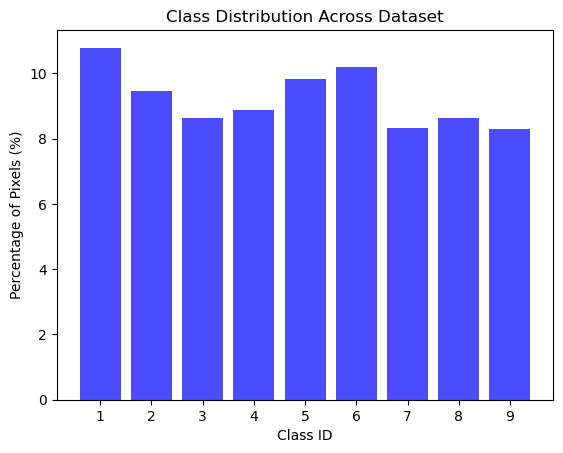

{1: 10.788065530833586,
 2: 9.452752356526348,
 3: 8.637180709607813,
 4: 8.875990462693064,
 5: 9.841447595680648,
 6: 10.204434871384766,
 7: 8.336640790619322,
 8: 8.636337825560267,
 9: 8.284211924117958}

In [13]:
calculate_overall_class_distribution(train_labels, False)


# GAN model

## Generator

In [27]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=4, dim_ff=512, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim_ff),
            nn.GELU(),
            nn.Linear(dim_ff, dim),
        )

    def forward(self, x):
        x_res = x
        x = self.norm1(x)
        x, _ = self.attn(x, x, x)
        x = x + x_res

        x_res = x
        x = self.norm2(x)
        x = self.ff(x) + x_res
        return x
    
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
            nn.ReLU(),
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
        )

    def forward(self, x):
        return x + self.block(x)
    
class UNetTransformerGenerator(nn.Module):
    def __init__(self, in_channels=14, out_channels=4, emb_dim=512, num_heads=8, depth=4):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels, 64, 3, padding=1)), 
            nn.ReLU(),
            spectral_norm(nn.Conv2d(64, 64, 3, padding=1)), 
            nn.ELU(),
            ResidualBlock(64)
        )
        self.enc2 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(64, 128, 3, padding=1)),
            nn.GELU(),
            ResidualBlock(128)
        )
        self.enc3 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(128, 256, 3, padding=1)),
            nn.ReLU(),
            ResidualBlock(256)
        )
        self.enc4 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(256, emb_dim, 3, padding=1)),  # 512 default
            nn.GELU(),
            ResidualBlock(emb_dim)
        )

        # Transformer
        self.flatten = nn.Flatten(2)
        self.transformers = nn.Sequential(*[
            TransformerBlock(emb_dim, heads=num_heads) for _ in range(depth)
        ])
        self.unflatten = lambda x: x.view(x.size(0), emb_dim, 8, 8)

        # Decoder
        self.dec4 = nn.Sequential(
            ResidualBlock(emb_dim),
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(emb_dim, 256, 3, padding=1)),
            nn.ReLU()
        )
        self.dec3 = nn.Sequential(
            ResidualBlock(512),  # 256 from dec4 + 256 from enc3
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(512, 128, 3, padding=1)),
            nn.ReLU()
        )
        self.dec2 = nn.Sequential(
            ResidualBlock(256),  # 128 + 128
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(256, 64, 3, padding=1)),
            nn.ReLU()
        )
        self.dec1 = nn.Sequential(
            ResidualBlock(128),  # 64 + 64
            spectral_norm(nn.Conv2d(128, out_channels, 3, padding=1)),
            nn.Tanh()
        )

    def forward(self, noise, label_map):
        x = torch.cat([noise, label_map], dim=1)  # [B, 14, 64, 64]

        e1 = self.enc1(x)        # [B, 64, 64, 64]
        e2 = self.enc2(e1)       # [B, 128, 32, 32]
        e3 = self.enc3(e2)       # [B, 256, 16, 16]
        e4 = self.enc4(e3)       # [B, 512, 8, 8]

        x_flat = self.flatten(e4).permute(0, 2, 1)  # [B, 64, 512]
        x_trans = self.transformers(x_flat)
        x_unflat = self.unflatten(x_trans.permute(0, 2, 1))  # [B, 512, 8, 8]

        d4 = self.dec4(x_unflat)                         # [B, 256, 16, 16]
        d3 = self.dec3(torch.cat([d4, e3], dim=1))       # [B, 128, 32, 32]
        d2 = self.dec2(torch.cat([d3, e2], dim=1))       # [B, 64, 64, 64]
        d1 = self.dec1(torch.cat([d2, e1], dim=1))       # [B, out_channels, 64, 64]

        return d1


## Discriminator

In [28]:
class DiscriminatorWithLabelEmbedding(nn.Module):
    def __init__(self, in_channels=4, label_classes=10, base_channels=64):
        super().__init__()

        self.img_conv = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 4, 2, 1),  # [B, 64, 32, 32]
            nn.LeakyReLU(0.2)
        )

        self.label_embed = nn.Sequential(
            nn.Conv2d(label_classes, base_channels, 4, 2, 1),
            nn.LeakyReLU(0.2)
        )

        # Save layers individually to extract features
        self.conv1 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, 4, 2, 1),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.final = nn.Conv2d(base_channels * 4, 1, 8)  # [B, 1, 1, 1]

    def forward(self, img, label_map):
        label_map = label_map.float()
        img_feat = self.img_conv(img.float())           # [B, 64, 32, 32]
        label_feat = self.label_embed(label_map)        # [B, 64, 32, 32]
        x = torch.cat([img_feat, label_feat], dim=1)    # [B, 128, 32, 32]

        feats = []

        x = self.conv1(x)        
        feats.append(x.mean([2, 3]))  # Global avg pooled features

        x = self.conv2(x)
        feats.append(x.mean([2, 3]))

        out = self.final(x)               # [B, 1, 1, 1]
        out = out.view(-1, 1)

        return out, feats


## Helper functions

In [29]:
def load_models(generator, discriminator, g_optimizer, d_optimizer, path):
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=True)
    
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    g_optimizer.load_state_dict(checkpoint['g_optimizer_state_dict'])
    d_optimizer.load_state_dict(checkpoint['d_optimizer_state_dict'])
    
    epoch = checkpoint.get('epoch', 0)
    print(f"Models loaded from {path} (Epoch {epoch})")
    return epoch

def save_models(generator, discriminator, g_optimizer, d_optimizer, epoch, path, modelid=0):
    epoch+=1

    filename = r'/acgan_checkpoint-Model '+str(modelid)+r'-Epoch '+str(epoch)+r'_'+ str(datetime.date.today()) +r'.pth'
    full_path = path + filename
    #print(full_path)

    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'g_optimizer_state_dict': g_optimizer.state_dict(),
        'd_optimizer_state_dict': d_optimizer.state_dict(),
    }, full_path)
    
    print(f"Models saved to {full_path}")


## Training loop

In [30]:
def safe_grad_mean(param):
    if param.grad is not None:
        return param.grad.abs().mean().item()
    return 0.0

def train_cgan_transformer(generator, discriminator, g_optimizer, d_optimizer, dataloader, epochs, modelid=1, gen_iter=2, lamda=0.1):
    DEVICE = next(generator.parameters()).device
    loss_fn = torch.nn.BCEWithLogitsLoss(reduction="mean")
    
    losses_g, losses_d = [], []

    for epoch in range(epochs):
        gen_loss_epoch = 0.0
        disc_loss_epoch = 0.0

        for real_imgs, labels in dataloader:
            real_imgs = real_imgs.to(DEVICE).float()      # [B, 4, 64, 64]
            labels = labels.to(DEVICE).long()            # [B, 64, 64]

            B = real_imgs.size(0)

            # One-hot encode labels: [B, H, W] → [B, 10, H, W]
            one_hot_labels = F.one_hot(labels, num_classes=10).permute(0, 3, 1, 2).float()

            # ----------------------
            # Train Discriminator
            # ----------------------
            noise = torch.randn(B, 4, 64, 64).to(DEVICE)
            fake_imgs = generator(noise, one_hot_labels).detach()  # No grad for D

            # Soft labels
            real_targets = torch.empty(B, 1).uniform_(0.9, 1.0).to(DEVICE)
            fake_targets = torch.empty(B, 1).uniform_(0.0, 0.1).to(DEVICE)

            d_real, _ = discriminator(real_imgs, one_hot_labels)
            d_fake, _ = discriminator(fake_imgs, one_hot_labels)

            # To confuse the discriminator and to allow the generator to train more effectivelly
            if torch.rand(1).item() < 0.1:
                real_targets, fake_targets = fake_targets, real_targets 

            disc_loss = loss_fn(d_real, real_targets) + \
                        loss_fn(d_fake, fake_targets)

            #disc_loss = hinge_d_loss(d_real, d_fake)

            d_optimizer.zero_grad()
            disc_loss.backward()
            d_optimizer.step()            

            # ----------------------
            # Train Generator
            # ----------------------
            # Train Generator
            g_iter_loss = 0.0

            for _ in range(gen_iter): 
                noise = torch.randn(B, 4, 64, 64).to(DEVICE)
                fake_imgs = generator(noise, one_hot_labels)
                fake_imgs = fake_imgs + 0.05 * torch.randn_like(fake_imgs)

                # Standard BCE loss
                g_pred, fake_feats = discriminator(fake_imgs, one_hot_labels.detach())
                g_targets = torch.ones(B, 1).to(DEVICE)
                adv_loss = loss_fn(g_pred, g_targets)

                # Feature Matching Loss
                with torch.no_grad():
                    _, real_feats = discriminator(real_imgs, one_hot_labels)

                feat_match_loss = 0.0
                for rf, ff in zip(real_feats, fake_feats):
                    feat_match_loss += F.l1_loss(ff, rf.detach())

                # Combine losses
                #gen_loss = adv_loss + lamda * feat_match_loss  # scale FM loss
                recon_loss = F.l1_loss(fake_imgs, real_imgs)
                gen_loss = adv_loss + lamda * feat_match_loss + 100 * recon_loss

                g_optimizer.zero_grad()
                gen_loss.backward()
                g_optimizer.step()

                g_iter_loss += gen_loss.item()

                
            gen_loss_epoch += (g_iter_loss/gen_iter)
            disc_loss_epoch += disc_loss.item()

        avg_g = gen_loss_epoch / len(dataloader)
        avg_d = disc_loss_epoch / len(dataloader)

        # Logging
        grad_g = safe_grad_mean(generator.enc1[0].weight_orig)
        grad_d = safe_grad_mean(discriminator.conv1[0].weight)
        print(f"Epoch {epoch+1} | discriminator Loss: {avg_d:.4f} | generator Loss: {avg_g:.4f} | Grad G: {grad_g:.6f}, Grad D: {grad_d:.6f}")
        
        losses_d.append(avg_d)
        losses_g.append(avg_g)

        # Save generated images every few epochs
        # if (epoch + 1) % 5 == 0:
        #     torchvision.utils.save_image(fake_imgs[:16], f"generated_epoch_{epoch+1}.png", normalize=True, nrow=4)
        # print(f"Epoch {epoch+1} | discriminator Loss: {avg_d:.4f} | generator Loss: {avg_g:.4f}")

        if ((epoch+1)%10) == 0:
            print("")
            save_models(generator, discriminator, g_optimizer, d_optimizer, epoch, modelid=modelid, path=r'../GAN models/Spatial models/NIR - based')
            print("")
        

    return losses_g, losses_d


# Model training

In [31]:
class ImageLabelDataset(Dataset):
    def __init__(self, image_array, label_array):
        self.images = torch.tensor(image_array, dtype=torch.float32)  # (N, 4, 64, 64)
        self.labels = torch.tensor(label_array, dtype=torch.float32)  # (N, 1, 64, 64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

image_data = np.transpose(train_data, (0, 3, 1, 2))  # (N, 4, 64, 64)

dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [ ]:
generator = UNetTransformerGenerator(depth=12).to(DEVICE)
discriminator = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-5, betas=(0.5, 0.999))

losses_g, losses_d = train_cgan_transformer(generator, discriminator, g_optimizer, d_optimizer, loader, epochs=500, modelid=8, gen_iter=5)


Epoch 1 | discriminator Loss: 1.3895 | generator Loss: 30.4368 | Grad G: 0.084363, Grad D: 0.048043
Epoch 2 | discriminator Loss: 1.3301 | generator Loss: 25.4905 | Grad G: 0.201630, Grad D: 0.058841
Epoch 3 | discriminator Loss: 1.2506 | generator Loss: 25.0211 | Grad G: 0.200907, Grad D: 0.078165
Epoch 4 | discriminator Loss: 1.1185 | generator Loss: 24.5616 | Grad G: 0.334573, Grad D: 0.082409
Epoch 5 | discriminator Loss: 1.0100 | generator Loss: 24.4599 | Grad G: 0.172941, Grad D: 0.111369
Epoch 6 | discriminator Loss: 1.0920 | generator Loss: 24.1510 | Grad G: 0.133252, Grad D: 0.183392
Epoch 7 | discriminator Loss: 1.0787 | generator Loss: 24.1881 | Grad G: 0.194286, Grad D: 0.201539
Epoch 8 | discriminator Loss: 1.0263 | generator Loss: 23.9008 | Grad G: 0.065990, Grad D: 0.243925
Epoch 9 | discriminator Loss: 0.9446 | generator Loss: 23.7412 | Grad G: 0.052270, Grad D: 0.209837
Epoch 10 | discriminator Loss: 1.0738 | generator Loss: 23.3901 | Grad G: 0.055797, Grad D: 0.323385

In [ ]:
noise_dim = 100

# generator = Generator(depth=12).to(DEVICE)
# discriminator = Discriminator(depth=12).to(DEVICE)

generator = UNetTransformerGenerator(depth=8).to(DEVICE)
discriminator = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-5, betas=(0.5, 0.999))

losses_g, losses_d = train_cgan_transformer(generator, discriminator, g_optimizer, d_optimizer, loader, epochs=150, modelid=5, gen_iter=5)


Epoch 1 | discriminator Loss: 1.3800 | generator Loss: 29.9924 | Grad G: 0.202676, Grad D: 0.041820
Epoch 2 | discriminator Loss: 1.3309 | generator Loss: 25.9066 | Grad G: 0.108521, Grad D: 0.056589
Epoch 3 | discriminator Loss: 1.2557 | generator Loss: 25.0713 | Grad G: 0.086262, Grad D: 0.087204
Epoch 4 | discriminator Loss: 1.0894 | generator Loss: 24.5760 | Grad G: 0.162273, Grad D: 0.084374
Epoch 5 | discriminator Loss: 1.0056 | generator Loss: 24.4323 | Grad G: 0.088528, Grad D: 0.183135
Epoch 6 | discriminator Loss: 0.9971 | generator Loss: 24.1352 | Grad G: 0.091789, Grad D: 0.199723
Epoch 7 | discriminator Loss: 1.0478 | generator Loss: 23.7616 | Grad G: 0.128304, Grad D: 0.256856
Epoch 8 | discriminator Loss: 0.9832 | generator Loss: 23.4446 | Grad G: 0.091323, Grad D: 0.179497
Epoch 9 | discriminator Loss: 0.9253 | generator Loss: 23.2323 | Grad G: 0.058778, Grad D: 0.256801
Epoch 10 | discriminator Loss: 0.9697 | generator Loss: 22.9796 | Grad G: 0.063561, Grad D: 0.182901

# Results analysis

## Model Data

In [135]:
# model_data = {
#     "id": 5,              # Integer value 
#     "start_epoch": 10,    # Integer
#     "end_epoch": 150,     # Integer
#     "depth": 8,          # No of layers,
#     "interval": 10,       # Model save frequency in epochs
#     "best_model": 60, # or 90    # Based on loss curves along with FID and KID scores
#     "date": "2025-08-02", # Format: YYYY-MM-DD  # Best model date
# }

# model_data = {
#     "id": 6,              # Integer value 
#     "start_epoch": 10,    # Integer
#     "end_epoch": 250,     # Integer
#     "depth": 4,           # No of layers,
#     "interval": 10,       # Model save frequency in epochs
#     "best_model": 80,     # Based on loss curves along with FID and KID scores 
#     "date": "2025-08-03", # Format: YYYY-MM-DD # Best model date
# }


model_data = {
    "id": 8,              # Integer value 
    "start_epoch": 10,    # Integer
    "end_epoch": 500,     # Integer
    "depth": 12,          # No of layers,
    "interval": 10,       # Model save frequency in epochs
    "best_model": 110,    # Based on loss curves along with FID and KID scores
    "date": "2025-08-11", # Format: YYYY-MM-DD  # Best model date
}

selected_model_path = "../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model "+ str(model_data["id"]) +"-Epoch "+str(model_data["best_model"])+"_"+model_data["date"]+".pth"


In [60]:
selected_model_path

'../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model 5-Epoch 90_2025-08-03.pth'

In [123]:
file = open('./Analysis files npy files/Spatial/Model 8/Model 8.txt')

line = file.readline()
losses_d = []
losses_g = []

# Epoch 31 | discriminator Loss: 1.1524 | generator Loss: 14.4668 | Grad G: 0.263934, Grad D: 0.274415
while line:
    epoch = line.strip()
    iterator, epoch = epoch.split('discriminator Loss: ')
    disc_loss, txt = epoch.split(' | generator Loss: ')
    gen_loss, _ = txt.split(' | Grad G:')
    # print(f"Itr: {iterator} | Disc loss: {disc_loss} | Gen loss: {gen_loss}")
    losses_d.append(float(disc_loss))
    losses_g.append(float(gen_loss))
    line = file.readline()
file.close()

## Helper functions

In [13]:
def display_images(data_patches):
    for i in range(data_patches.shape[0]):
        patch = data_patches[i,...]
        indices = [patch[...,0:3], patch[...,:],]
        titles = ['RGB', 'RGB-NIR']

        fig, axs = plt.subplots(1, 2, figsize=(16, 4))
        for ax, idx_map, title in zip(axs, indices, titles):
            im = ax.imshow(idx_map, cmap='RdYlGn', vmin=-1, vmax=1)
            ax.set_title(title)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()


In [35]:
@torch.no_grad()
def generate_and_save_images(G, num, outdir, epoch):
    os.makedirs(outdir, exist_ok=True)
    G.eval()

    idx = 0
    while idx<num:       
        image_no = random.randint(0, (num-1))
        
        validation_label_img1 = torch.tensor(np.array([validation_labels[image_no, ...]])).long().to(DEVICE)

        one_hot_labels = F.one_hot(validation_label_img1, num_classes=10).permute(0, 3, 1, 2).float()

        noise_image = torch.randn(1, 4, 64, 64).to(DEVICE)
        fake_image = generator(noise_image, one_hot_labels).detach() 

        save_image(fake_image, os.path.join(outdir, f"{idx:06d}.png"))

        idx += 1

def save_real_subset(dataloader, num, outdir):
    os.makedirs(outdir, exist_ok=True)
    saved = 0
    for imgs, *rest in dataloader:
        # imgs expected in [-1,1]; convert if needed
        imgs = (imgs.clamp(-1,1) + 1) / 2
        for i in range(imgs.size(0)):
            if saved >= num: break
            save_image(imgs[i], os.path.join(outdir, f"{saved:06d}.png"))
            saved += 1
        if saved >= num: break




## Loss plot

In [124]:
def plot_losses(losses_g, losses_d, save_path=None, individual_figures=False, show_grid=False):
    if individual_figures:
        plt.figure(figsize=(12,5))
        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(losses_d)+1), losses_d, label='Discriminator loss')
        plt.title('Discriminator loss curve')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')

        plt.subplot(1, 2, 2)
        plt.plot(range(1, len(losses_g)+1), losses_g, label='Generator loss')
        plt.title('Generator loss curve')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')


    else:
        plt.figure(figsize=(10, 5))
        plt.plot(losses_g, label='Generator Loss')
        plt.plot(losses_d, label='Discriminator Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Generator and Discriminator Loss Over Time")

    if save_path:
        plt.savefig(save_path)

    plt.grid(show_grid)
    plt.tight_layout()
    plt.show()
        


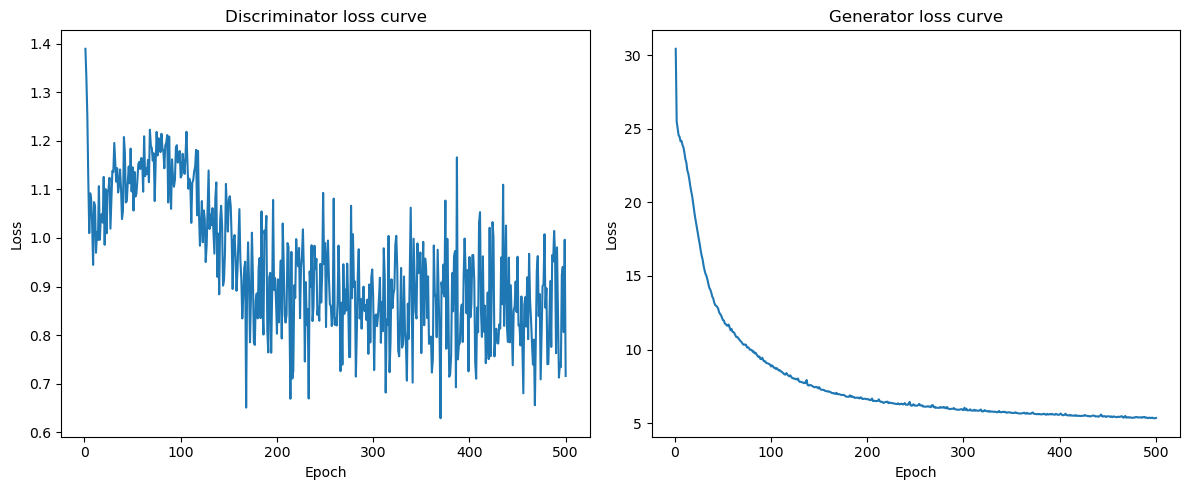

In [125]:
plot_losses(losses_g, losses_d, individual_figures=True)


## FID and KID scores

In [132]:
fid_list = []
kid_mean_lst = []
kid_std_lst = []
date_list_m8 = ['2025-08-08', '2025-08-09', '2025-08-09', '2025-08-09', '2025-08-09',
                '2025-08-10', '2025-08-10', '2025-08-10', '2025-08-10', '2025-08-11', 
                '2025-08-11', '2025-08-11', '2025-08-11', '2025-08-12', '2025-08-12', 
                '2025-08-12', '2025-08-12', '2025-08-13', '2025-08-13', '2025-08-13', 
                '2025-08-13', '2025-08-14', '2025-08-14', '2025-08-14', '2025-08-15', 
                '2025-08-15', '2025-08-15', '2025-08-15', '2025-08-16', '2025-08-16', 
                '2025-08-16', '2025-08-16', '2025-08-17', '2025-08-17', '2025-08-17', 
                '2025-08-17', '2025-08-18', '2025-08-18', '2025-08-18', '2025-08-18', 
                '2025-08-19', '2025-08-19', '2025-08-19', '2025-08-19', '2025-08-20', 
                '2025-08-20', '2025-08-20', '2025-08-20', '2025-08-21', '2025-08-21'] 

if(validation_data.shape[1] != 4):
    validation_data = np.transpose(validation_data, (0, 3, 1, 2)) 

dataset = ImageLabelDataset(validation_data, validation_labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

for i in range(model_data["start_epoch"], model_data["end_epoch"]+1, 10):
    # if i<90:
    #     selected_model_path = "../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model "+ str(model_data["id"]) +"-Epoch "+str(i)+"_2025-08-02.pth"
    # else:
    #     selected_model_path = "../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model "+ str(model_data["id"]) +"-Epoch "+str(i)+"_2025-08-03.pth"
    selected_model_path = "../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model "+ str(model_data["id"]) +"-Epoch "+str(i)+"_"+date_list_m8[int(i/10)-1]+".pth"
        
    generator = UNetTransformerGenerator(depth=model_data["depth"]).to(DEVICE)
    discriminator = DiscriminatorWithLabelEmbedding().to(DEVICE)

    g_optimizer = torch.optim.Adam(generator.parameters(), lr=2e-5, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-5, betas=(0.5, 0.999))

    _ = load_models(generator, discriminator, g_optimizer, d_optimizer, selected_model_path)

    num_samples = validation_labels.shape[0]
    real_dir  = "./FID_KID_results_and_saves/fid_real"
    fake_dir  = f"./FID_KID_results_and_saves/fid_fake"

    # 1) Save a matching number of real images
    save_real_subset(loader, num_samples, real_dir)

    # 2) Generate and save the same number of fake images
    generate_and_save_images(generator, num_samples, fake_dir, i)

    metrics = calculate_metrics(
    input1=real_dir,
    input2=fake_dir,
    fid=True,
    kid=True,
    verbose=False,
    cuda=False
    )

    fid_list.append(metrics['frechet_inception_distance'])
    kid_mean_lst.append(metrics['kernel_inception_distance_mean'])
    kid_std_lst.append(metrics['kernel_inception_distance_std'])

    print(f"Epoch: {i} | Fid: {metrics['frechet_inception_distance']} | KID mean: {metrics['kernel_inception_distance_mean']}")


Models loaded from ../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model 8-Epoch 10_2025-08-08.pth (Epoch 10)
Epoch: 10 | Fid: 226.89426336337385 | KID mean: 0.16122072333833834
Models loaded from ../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model 8-Epoch 20_2025-08-09.pth (Epoch 20)
Epoch: 20 | Fid: 200.43506396354059 | KID mean: 0.13018248739739735
Models loaded from ../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model 8-Epoch 30_2025-08-09.pth (Epoch 30)
Epoch: 30 | Fid: 197.93088795837463 | KID mean: 0.1254475526176176
Models loaded from ../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model 8-Epoch 40_2025-08-09.pth (Epoch 40)
Epoch: 40 | Fid: 195.81464293394106 | KID mean: 0.1223997633833834
Models loaded from ../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model 8-Epoch 50_2025-08-09.pth (Epoch 50)
Epoch: 50 | Fid: 192.74270296252735 | KID mean: 0.11482501272022022
Models loaded from ../GAN models/Spatial models/NIR - based/ac

In [133]:
fid_kid_array = np.array([fid_list, kid_mean_lst, kid_std_lst])
np.save('./model8_FID_KID_stats.npy', fid_kid_array)

print(fid_kid_array.shape)


(3, 50)


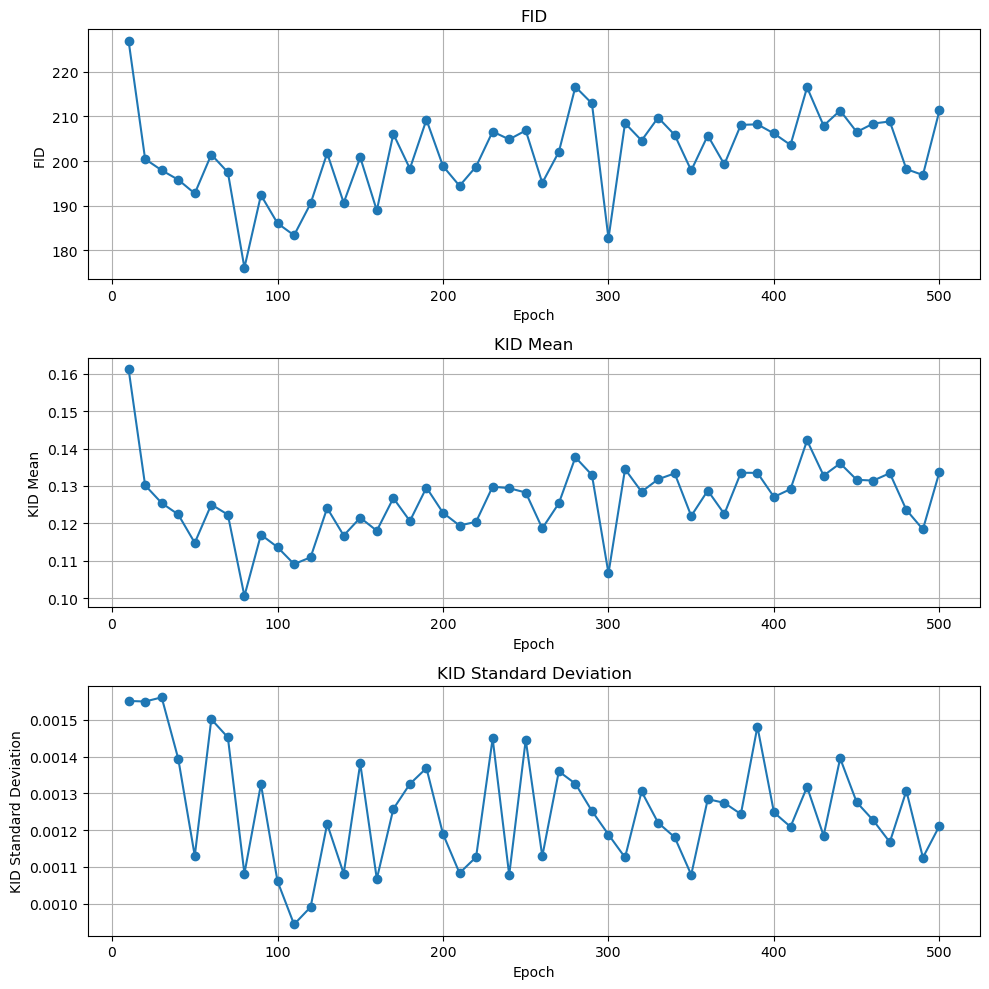

In [134]:
epochs = np.arange(10, (fid_kid_array.shape[1]*10)+1, 10)

# Titles for each metric
titles = ['FID', 'KID Mean', 'KID Standard Deviation']

# Plot each metric in a separate subplot
plt.figure(figsize=(10, 10))

for i in range(3):
    plt.subplot(3, 1, i + 1)
    plt.plot(epochs, fid_kid_array[i], marker='o', label=titles[i])
    plt.title(titles[i])
    plt.xlabel('Epoch')
    plt.ylabel(titles[i])
    plt.grid(True)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


## Generate images

## Load model

In [136]:
generator = UNetTransformerGenerator(depth=model_data["depth"]).to(DEVICE)
discriminator = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-5, betas=(0.5, 0.999))

_ = load_models(generator, discriminator, g_optimizer, d_optimizer, selected_model_path)


Models loaded from ../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model 8-Epoch 110_2025-08-11.pth (Epoch 110)


## Visualise image

(1101, 4, 64, 64)
Original Image
torch.Size([1, 64, 64, 4])


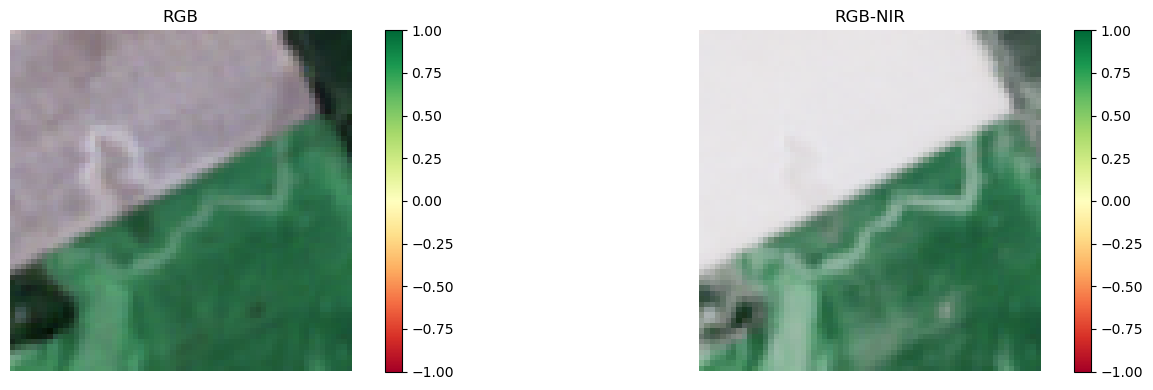

Generated Image


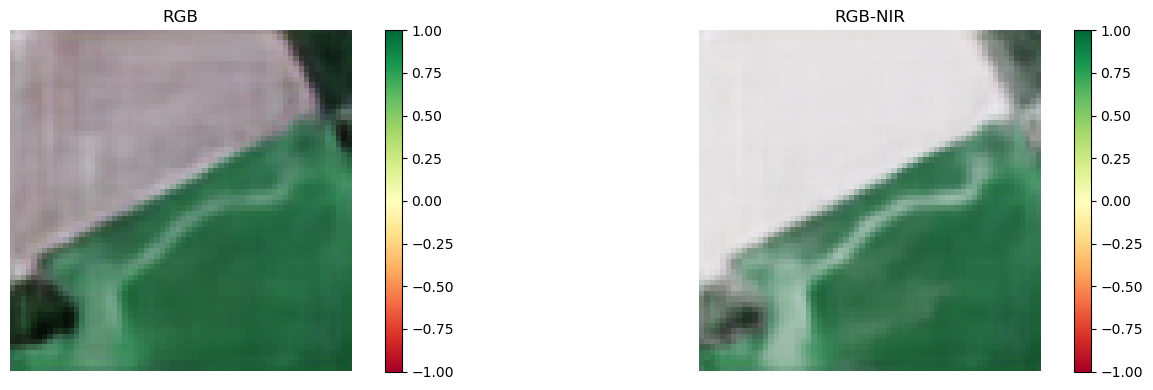

In [137]:
image_no = 2

print(validation_data.shape)
# validation_data_reprojected = np.transpose(validation_data, (0, 3, 1, 2))
# validation_data_img1 = torch.tensor(np.array([validation_data_reprojected[image_no, ...]]))
validation_data_reprojected = np.transpose(validation_data, (0, 2, 3, 1))
validation_data_img1 = torch.tensor(np.array([validation_data_reprojected[image_no, ...]]))

validation_data_img1 = (validation_data_img1+1)/2

print("Original Image")
print(validation_data_img1.shape)
display_images(validation_data_img1)

validation_label_img1 = torch.tensor(np.array([validation_labels[image_no, ...]])).long().to(DEVICE)
one_hot_labels = F.one_hot(validation_label_img1, num_classes=10).permute(0, 3, 1, 2).float()

noise_image = torch.randn(1, 4, 64, 64).to(DEVICE)
#noise_image = (validation_data_img1 + 0.05 * torch.randn_like(validation_data_img1)).to(DEVICE).float()
fake_image = generator(noise_image, one_hot_labels).detach() 
fake_image = (fake_image+1)/2

print("Generated Image")
# print(fake_imgs.shape)
display_images(fake_image.permute(0, 2, 3, 1).cpu().numpy())


## Generate image set

In [138]:
validation_data.shape

(1101, 4, 64, 64)

In [139]:
generated_images = np.empty((0, 4, 64, 64))

assert validation_data.shape[1:] == generated_images.shape[1:]

for image_no in tqdm(range(validation_data.shape[0])): 
    validation_label_img1 = torch.tensor(np.array([validation_labels[image_no, ...]])).long().to(DEVICE)

    one_hot_labels = F.one_hot(validation_label_img1, num_classes=10).permute(0, 3, 1, 2).float()

    noise_image = torch.randn(1, 4, 64, 64).to(DEVICE)
    fake_image = generator(noise_image, one_hot_labels).detach() 

    generated_images = np.concatenate((generated_images, np.array(fake_image.cpu())), axis=0)


100%|██████████| 1101/1101 [05:51<00:00,  3.13it/s]


## Save image set

In [141]:
generated_data_reprojected = torch.tensor(generated_images).to(DEVICE).permute(0,2,3,1).cpu().numpy()
#np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/DS3/13_generated_images_model_8_epoch_440.npy', generated_images)


## Laplacian mean and variance plots

In [142]:
print(validation_data.shape)
print(generated_images.shape)

print(validation_data_reprojected.shape)
print(generated_data_reprojected.shape)



(1101, 4, 64, 64)
(1101, 4, 64, 64)
(1101, 64, 64, 4)
(1101, 64, 64, 4)


In [143]:
normalized_real_images = (validation_data + 1) / 2

normalized_generated_images = (generated_images + 1) / 2

real_images_rgb_alpha = normalized_real_images * 255
real_images_rgb_alpha = real_images_rgb_alpha.astype(np.uint8)

# Generated images: N_images x 64 x 64 x 4
generated_images_rgb_alpha = normalized_generated_images * 255
generated_images_rgb_alpha = generated_images_rgb_alpha.astype(np.uint8)

# Calculate Mean and Variance of Laplacian for each image
real_laplacian_means = []
real_laplacian_variances = []
generated_laplacian_means = []
generated_laplacian_variances = []

for i in range(normalized_real_images.shape[0]):
    # For Laplacian, it's typically applied to grayscale images
    # Convert from 4 channels (RGBA) to 3 channels (RGB) then to grayscale
    # OpenCV's cvtColor expects BGR, so we'll treat the first 3 channels as such
    real_rgb = real_images_rgb_alpha[i, :, :, :3]
    real_gray = cv2.cvtColor(real_rgb, cv2.COLOR_RGB2GRAY)
    
    # Calculate Laplacian
    # Use CV_64F for higher precision to handle potential negative values
    real_laplacian = cv2.Laplacian(real_gray, cv2.CV_64F)
    
    # Calculate mean and variance of the Laplacian image
    real_laplacian_means.append(np.mean(real_laplacian))
    real_laplacian_variances.append(np.var(real_laplacian))

    # Repeat for generated images
    generated_rgb = generated_images_rgb_alpha[i, :, :, :3]
    generated_gray = cv2.cvtColor(generated_rgb, cv2.COLOR_RGB2GRAY)
    generated_laplacian = cv2.Laplacian(generated_gray, cv2.CV_64F)
    generated_laplacian_means.append(np.mean(generated_laplacian))
    generated_laplacian_variances.append(np.var(generated_laplacian))

# Prepare data for candle chart plotting (Mean of Laplacian)
# For real images
real_mean_laplacian_min = np.min(real_laplacian_means)
real_mean_laplacian_q1 = np.percentile(real_laplacian_means, 25)
real_mean_laplacian_median = np.median(real_laplacian_means)
real_mean_laplacian_q3 = np.percentile(real_laplacian_means, 75)
real_mean_laplacian_max = np.max(real_laplacian_means)

# For generated images
generated_mean_laplacian_min = np.min(generated_laplacian_means)
generated_mean_laplacian_q1 = np.percentile(generated_laplacian_means, 25)
generated_mean_laplacian_median = np.median(generated_laplacian_means)
generated_mean_laplacian_q3 = np.percentile(generated_laplacian_means, 75)
generated_mean_laplacian_max = np.max(generated_laplacian_means)

# 4. Plot Mean of Laplacian on a Candle Chart
fig_mean = go.Figure(data=[
    go.Candlestick(
        x=['Real Images'],
        open=[real_mean_laplacian_q1],
        high=[real_mean_laplacian_max],
        low=[real_mean_laplacian_min],
        close=[real_mean_laplacian_q3],
        name='Real Images',
        increasing_line_color='blue',
        decreasing_line_color='blue'
    ),
    go.Candlestick(
        x=['Generated Images'],
        open=[generated_mean_laplacian_q1],
        high=[generated_mean_laplacian_max],
        low=[generated_mean_laplacian_min],
        close=[generated_mean_laplacian_q3],
        name='Generated Images',
        increasing_line_color='red',
        decreasing_line_color='red'
    )
])

fig_mean.update_layout(
    title='Distribution of Mean of Laplacian for Images',
    yaxis_title='Mean Laplacian Value',
    width=1000,
    height=1000,
)

fig_mean.show()

# 5. Prepare data for candle chart plotting (Variance of Laplacian)
# For real images
real_var_laplacian_min = np.min(real_laplacian_variances)
real_var_laplacian_q1 = np.percentile(real_laplacian_variances, 25)
real_var_laplacian_median = np.median(real_laplacian_variances)
real_var_laplacian_q3 = np.percentile(real_laplacian_variances, 75)
real_var_laplacian_max = np.max(real_laplacian_variances)

# For generated images
generated_var_laplacian_min = np.min(generated_laplacian_variances)
generated_var_laplacian_q1 = np.percentile(generated_laplacian_variances, 25)
generated_var_laplacian_median = np.median(generated_laplacian_variances)
generated_var_laplacian_q3 = np.percentile(generated_laplacian_variances, 75)
generated_var_laplacian_max = np.max(generated_laplacian_variances)

# 6. Plot Variance of Laplacian on a Candle Chart
fig_var = go.Figure(data=[
    go.Candlestick(
        x=['Real Images'],
        open=[real_var_laplacian_q1],
        high=[real_var_laplacian_max],
        low=[real_var_laplacian_min],
        close=[real_var_laplacian_q3],
        name='Real Images',
        increasing_line_color='blue',
        decreasing_line_color='blue'
    ),
    go.Candlestick(
        x=['Generated Images'],
        open=[generated_var_laplacian_q1],
        high=[generated_var_laplacian_max],
        low=[generated_var_laplacian_min],
        close=[generated_var_laplacian_q3],
        name='Generated Images',
        increasing_line_color='red',
        decreasing_line_color='red'
    )
])

fig_var.update_layout(
    title='Distribution of Variance of Laplacian for Images',
    yaxis_title='Variance Laplacian Value',
    width=1000,
    height=1000
)

fig_var.show()


## RGB histogram plots

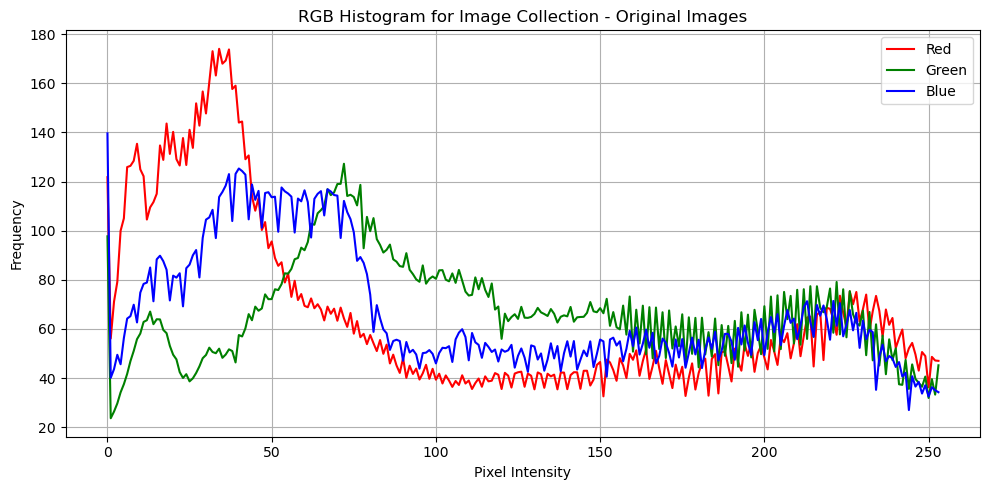

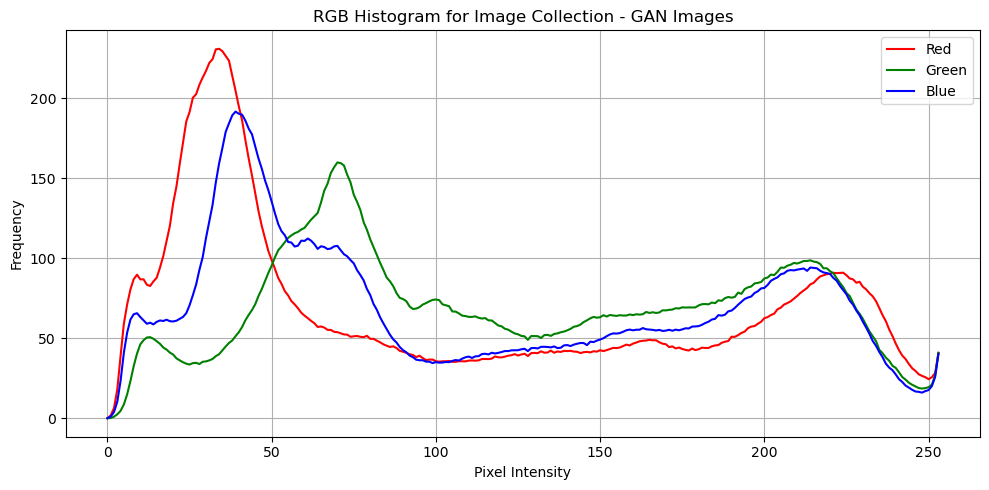

In [144]:
def compute_rgb_histogram(images):
    n, h, w, c = images.shape
    assert c == 4, "Expected 4 channels (RGBA)"
    
    # Initialize histograms
    hist_r = np.zeros(256)
    hist_g = np.zeros(256)
    hist_b = np.zeros(256)

    # Loop through each image
    for i in range(n):
        img = images[i, :, :, :3]  # Take only RGB, ignore Alpha

        denormalised_images = np.clip((img+1)*0.5*255, 0, 255).astype(np.float16)

        # Flatten each channel and compute histogram
        r_vals = denormalised_images[:, :, 0].flatten()
        g_vals = denormalised_images[:, :, 1].flatten()
        b_vals = denormalised_images[:, :, 2].flatten()

        hist_r += np.histogram(r_vals, bins=256, range=(0, 256))[0]/255
        hist_g += np.histogram(g_vals, bins=256, range=(0, 256))[0]/255
        hist_b += np.histogram(b_vals, bins=256, range=(0, 256))[0]/255

    return hist_r, hist_g, hist_b

def plot_rgb_histogram(hist_r, hist_g, hist_b, title):
    plt.figure(figsize=(10, 5))
    plt.plot(hist_r, color='r', label='Red')
    plt.plot(hist_g, color='g', label='Green')
    plt.plot(hist_b, color='b', label='Blue')
    plt.title('RGB Histogram for Image Collection - '+ title)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

hist_r, hist_g, hist_b = compute_rgb_histogram(validation_data_reprojected)
plot_rgb_histogram(hist_r[:254], hist_g[:254], hist_b[:254], 'Original Images')


hist_r, hist_g, hist_b = compute_rgb_histogram(generated_data_reprojected)
plot_rgb_histogram(hist_r[:254], hist_g[:254], hist_b[:254], 'GAN Images')


## Full set

### Calculate Wilcoxon values

In [145]:
# Feature Extraction
# Flatten each image and calculate the mean pixel intensity
real_features = np.mean(validation_data.reshape(validation_data.shape[0], -1), axis=1)
generated_features = np.mean(generated_images.reshape(generated_images.shape[0], -1), axis=1)


# Perform the Wilcoxon Signed-Rank Test
statistic, p_value = wilcoxon(real_features, generated_features)

print(f"Wilcoxon Signed-Rank Test Results:")
print(f"  Statistic: {statistic}")
print(f"  P-value: {p_value}")

# Interpret the results
alpha = 0.05

if p_value < alpha:
    print(f"\nSince p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference between the features of the real and generated images.")
else:
    print(f"\nSince p-value ({p_value:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference between the features of the real and generated images.")


Wilcoxon Signed-Rank Test Results:
  Statistic: 267771.0
  P-value: 0.0007542554809543908

Since p-value (0.0008) < alpha (0.05), we reject the null hypothesis.
Conclusion: There is a statistically significant difference between the features of the real and generated images.


### SSIM score and LPIPS values

In [146]:
def compute_ssim_per_channel(real, generated):
    """Computes average SSIM over each channel (assuming 4 channels)."""
    ssim_scores = []
    for ch in range(real.shape[-1]):
        score = ssim(real[..., ch], generated[..., ch], data_range=real[..., ch].max() - real[..., ch].min())
        ssim_scores.append(score)
    return np.mean(ssim_scores)

def ssim_analysis(real_images, generated_images):
    """Performs SSIM analysis over a dataset."""
    scores = []
    for real, fake in zip(real_images, generated_images):
        score = compute_ssim_per_channel(real, fake)
        scores.append(score)
    return np.mean(scores), scores  # mean SSIM, list of SSIMs


In [147]:
# LPIPS uses normalized 3-channel images in [-1, 1]
loss_fn = lpips.LPIPS(net='alex')  # or 'vgg'

def preprocess_for_lpips(img_batch):
    """Convert (N, 64, 64, 3) numpy image to torch tensor in [-1, 1]"""
    img_batch = img_batch[..., :3]  # Take RGB
    img_batch = img_batch.transpose(0, 3, 1, 2)  # NCHW
    img_batch = (img_batch / 127.5) - 1.0  # Normalize to [-1, 1]
    return torch.tensor(img_batch, dtype=torch.float32)

def lpips_analysis(real_images, generated_images):
    """Computes LPIPS for each image pair."""
    real_tensor = preprocess_for_lpips(real_images)
    gen_tensor = preprocess_for_lpips(generated_images)

    scores = []
    for r, g in zip(real_tensor, gen_tensor):
        score = loss_fn(r.unsqueeze(0), g.unsqueeze(0))
        scores.append(score.item())
    return np.mean(scores), scores 


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\2405647\.conda\envs\myenv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

c:\Users\2405647\.conda\envs\myenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.



Loading model from: c:\Users\2405647\.conda\envs\myenv\lib\site-packages\lpips\weights\v0.1\alex.pth


c:\Users\2405647\.conda\envs\myenv\lib\site-packages\lpips\lpips.py:107: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



In [148]:
mean_ssim, ssim_scores = ssim_analysis(validation_data_reprojected, generated_data_reprojected)
mean_lpips, lpips_scores = lpips_analysis(validation_data_reprojected, generated_data_reprojected)

print(f"Mean SSIM: {mean_ssim:.4f}")
print(f"Mean LPIPS: {mean_lpips:.4f}")


Mean SSIM: 0.2836
Mean LPIPS: 0.0001


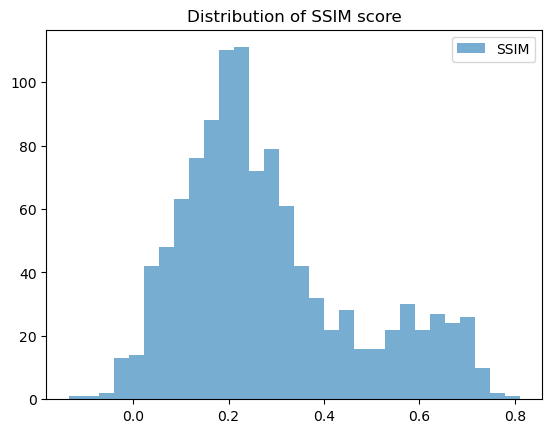

In [149]:
plt.hist(ssim_scores, bins=30, alpha=0.6, label='SSIM')
plt.legend()
plt.title('Distribution of SSIM score')
plt.show()


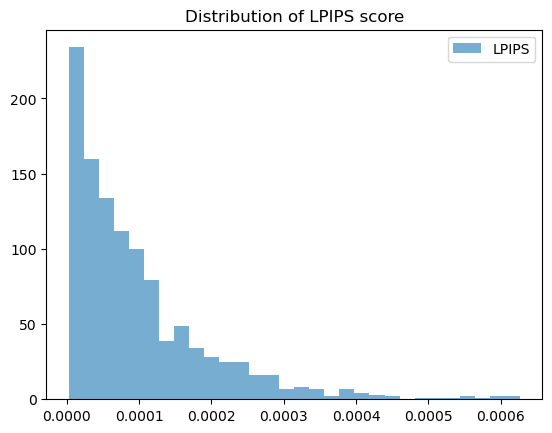

In [150]:
plt.hist(lpips_scores, bins=30, alpha=0.6, label='LPIPS')
plt.legend()
plt.title('Distribution of LPIPS score')
plt.show()


## Small set of size 100 images

### Calculate Wilcoxon values

In [151]:
random.seed(12)
radom_samples_id = random.sample(range(validation_data.shape[0]), 100)

In [152]:
# Feature Extraction
# Flatten each image and calculate the mean pixel intensity
val_sub_array = validation_data[radom_samples_id, ...]
gan_sub_array = generated_images[radom_samples_id, ...]

real_features = np.mean(val_sub_array.reshape(val_sub_array.shape[0], -1), axis=1)
generated_features = np.mean(gan_sub_array.reshape(gan_sub_array.shape[0], -1), axis=1)


# Perform the Wilcoxon Signed-Rank Test
statistic, p_value = wilcoxon(real_features, generated_features)

print(f"Wilcoxon Signed-Rank Test Results:")
print(f"  Statistic: {statistic}")
print(f"  P-value: {p_value}")

# Interpret the results
alpha = 0.05

if p_value < alpha:
    print(f"\nSince p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference between the features of the real and generated images.")
else:
    print(f"\nSince p-value ({p_value:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference between the features of the real and generated images.")


Wilcoxon Signed-Rank Test Results:
  Statistic: 2191.0
  P-value: 0.25080326830824096

Since p-value (0.2508) >= alpha (0.05), we fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference between the features of the real and generated images.


In [153]:
val_sub_array_reprojected = np.transpose(val_sub_array, (0, 2, 3, 1))
gan_sub_array_reprojected = np.transpose(gan_sub_array, (0, 2, 3, 1))

mean_ssim, ssim_scores = ssim_analysis(val_sub_array_reprojected, gan_sub_array_reprojected)
mean_lpips, lpips_scores = lpips_analysis(val_sub_array_reprojected, gan_sub_array_reprojected)

print(f"Mean SSIM: {mean_ssim:.4f}")
print(f"Mean LPIPS: {mean_lpips:.4f}")


Mean SSIM: 0.2976
Mean LPIPS: 0.0001


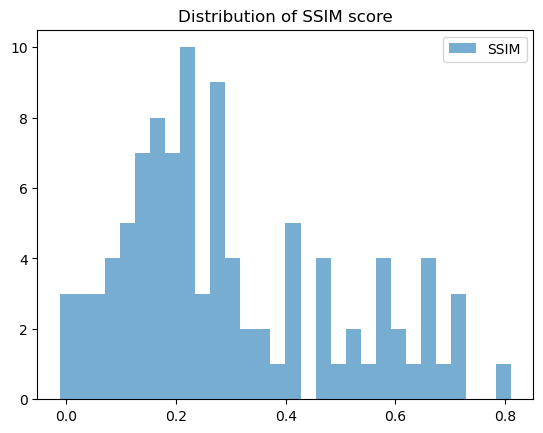

In [154]:
plt.hist(ssim_scores, bins=30, alpha=0.6, label='SSIM')
plt.legend()
plt.title('Distribution of SSIM score')
plt.show()


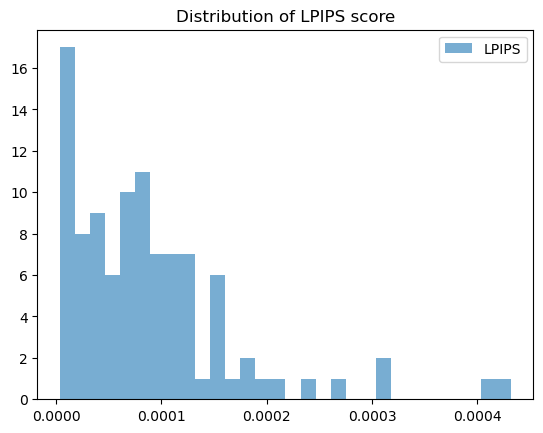

In [155]:
plt.hist(lpips_scores, bins=30, alpha=0.6, label='LPIPS')
plt.legend()
plt.title('Distribution of LPIPS score')
plt.show()
